In [2]:
import warnings
import numpy as np
from tqdm import tqdm

# Para evitar warning de divisão por zero
warnings.simplefilter(action='ignore')

def NLM(img, h, f, t):

    
    # Dimenssões espaciais da imagem
    m, n = img.shape

    # Cria imagem de saída
    filtrada = np.zeros((m, n))

    # Problema de valor de contorno: replicar bordas
    #img_n = np.pad(ruidosa, ((f, f), (f, f)), 'symmetric') # Modifiquei esta linha
    img_n = np.pad(img, ((f, f), (f, f)), 'symmetric')


    # Initializing the counter
    prog = tqdm(total=m*n, position=0, leave=True)

    # Loop principal do NLM
    for i in range(m):
        for j in range(n):

            im = i + f;   # compensar a borda adicionada artificialmente
            jn = j + f;   # compensar a borda adicionada artificialmente

            # Obtém o patch ao redor do pixel corrente
            W1 = img_n[im-f:(im+f)+1, jn-f:(jn+f)+1]

            # Calcula as bordas da janela de busca para o pixel corrente (se pixel próximo das bordas, janela de busca é menor)
            rmin = max(im-t, f);  # linha inicial
            rmax = min(im+t, m+f);  # linha final
            smin = max(jn-t, f);  # coluna inicial
            smax = min(jn+t, n+f);  # coluna final

            # Calcula média ponderada
            NL = 0      # valor do pixel corrente filtrado
            Z = 0       # constante normalizadora

            # Loop para todos os pixels da janela de busca
            for r in range(rmin, rmax):
                for s in range(smin, smax):

                    # Obtém o patch ao redor do pixel a ser comparado
                    W2 = img_n[r-f:(r+f)+1, s-f:(s+f)+1]

                    # Calcula o quadrado da distância Euclidiana
                    d2 = np.sum((W1 - W2)*(W1 - W2))

                    # Calcula a medida de similaridade
                    sij = np.exp(-d2/(h**2))

                    # Atualiza Z e NL
                    Z = Z + sij
                    NL = NL + sij*img_n[r, s]

            # Normalização do pixel filtrado
            filtrada[i, j] = NL/Z
            prog.update(1)
    return filtrada

In [ ]:
import cv2
img = cv2.imread("images/Lenna_ruidosa.png", cv2.IMREAD_GRAYSCALE)

filtrada = NLM(img,1,3,10)

### NLM versão ChatGpt

In [ ]:
import cv2
import numpy as np

def non_local_means_denoising(image, h=10, patch_size=5, search_size=17):
    """
    Implementação do Non-Local Means (NLM) para remoção de ruído.
    :param image: Imagem de entrada (numpy array, escala de cinza).
    :param h: Fator de filtragem (maior valor remove mais ruído, mas pode borrar a imagem).
    :param patch_size: Tamanho do patch (área considerada para similaridade local).
    :param search_size: Tamanho da área de busca ao redor de cada pixel.
    :return: Imagem filtrada.
    """
    
    # Converte para float para evitar problemas de precisão
    image = image.astype(np.float32)
    
    # Dimensões da imagem
    rows, cols = image.shape
    
    # Define metade dos tamanhos
    half_patch = patch_size // 2
    half_search = search_size // 2
    
    # Resultado final
    filtered_image = np.zeros_like(image)
    
    # Pad para lidar com bordas
    padded_image = cv2.copyMakeBorder(image, half_search, half_search, half_search, half_search, cv2.BORDER_REFLECT)
    
    for i in range(rows):
        for j in range(cols):
            i_p = i + half_search
            j_p = j + half_search
            
            # Extrai o patch central
            patch_center = padded_image[i_p - half_patch:i_p + half_patch + 1, j_p - half_patch:j_p + half_patch + 1]
            
            weights = []
            values = []
            
            # Percorre a janela de busca
            for m in range(-half_search, half_search + 1):
                for n in range(-half_search, half_search + 1):
                    
                    if m == 0 and n == 0:
                        continue
                    
                    # Extrai o patch vizinho
                    patch_neighbor = padded_image[i_p + m - half_patch:i_p + m + half_patch + 1, j_p + n - half_patch:j_p + n + half_patch + 1]
                    
                    # Calcula a distância Euclidiana entre os patches
                    dist = np.sum((patch_center - patch_neighbor) ** 2)
                    weight = np.exp(-dist / (h ** 2))
                    
                    weights.append(weight)
                    values.append(padded_image[i_p + m, j_p + n])
            
            # Normaliza os pesos
            weights = np.array(weights)
            weights /= np.sum(weights)
            
            # Aplica os pesos aos valores e atribui ao pixel filtrado
            filtered_image[i, j] = np.sum(weights * np.array(values))
    
    return np.clip(filtered_image, 0, 255).astype(np.uint8)

# Exemplo de uso
if __name__ == "__main__":
    img = cv2.imread("ruidosa/ruidosa_salt_pepper.png", cv2.IMREAD_GRAYSCALE)
    denoised_img = non_local_means_denoising(img, h=10, patch_size=3, search_size=17)
    cv2.imwrite("imagem_denoised.jpg", denoised_img)
    cv2.imshow("Denoised Image", denoised_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


In [ ]:
from skimage import img_as_float
from skimage.util import random_noise
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

def non_local_means(image, patch_size=5, search_size=17, h=10):
    """
    Aplica o algoritmo Non-Local Means para remoção de ruído.
    - image: imagem de entrada (numpy array).
    - patch_size: tamanho do patch local (pequena vizinhança).
    - search_size: tamanho da área de busca para encontrar pixels semelhantes.
    - h: parâmetro de suavização (quanto maior, mais agressivo o filtro).
    """
    image = img_as_float(image)  # Normalizar para [0,1]
    filtered_image = np.zeros_like(image)
    pad_size = search_size // 2  # Padding para bordas
    padded_image = np.pad(image, pad_size, mode='reflect')

    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            i_p = i + pad_size
            j_p = j + pad_size
            
            patch = padded_image[i_p - patch_size//2 : i_p + patch_size//2 + 1, 
                                 j_p - patch_size//2 : j_p + patch_size//2 + 1]
            
            # Janela de busca
            search_window = padded_image[i_p - pad_size : i_p + pad_size + 1, 
                                         j_p - pad_size : j_p + pad_size + 1]

            # Computar pesos
            weights = np.zeros_like(search_window)
            for m in range(search_window.shape[0] - patch_size + 1):
                for n in range(search_window.shape[1] - patch_size + 1):
                    neighbor_patch = search_window[m:m+patch_size, n:n+patch_size]
                    distance = np.sum((patch - neighbor_patch) ** 2)
                    weights[m, n] = np.exp(-distance / (h ** 2))

            # Normalizar pesos e calcular pixel filtrado
            weights /= np.sum(weights)
            filtered_pixel = np.sum(weights * search_window)
            filtered_image[i, j] = filtered_pixel

    return filtered_image

# Criar imagem com ruído para teste
image = np.zeros((256, 256))
image[25:75, 25:75] = 1  # Quadrado branco
noisy_image = random_noise(image, var=0.02)  # Adicionar ruído

# Aplicar filtro
filtered_image = non_local_means(noisy_image)

# Exibir imagens
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(noisy_image, cmap="gray")
axs[0].set_title("Imagem com Ruído")
axs[0].axis("off")

axs[1].imshow(filtered_image, cmap="gray")
axs[1].set_title("Imagem Filtrada (NLM)")
axs[1].axis("off")

plt.show()


C:\Users\adria\AppData\Local\Temp\ipykernel_5156\1426259259.py:27: RuntimeWarning: overflow encountered in scalar subtract
  weight = abs(patch[i, j] - patch[i, j+1])
C:\Users\adria\AppData\Local\Temp\ipykernel_5156\1426259259.py:24: RuntimeWarning: overflow encountered in scalar subtract
  weight = abs(patch[i, j] - patch[i+1, j])


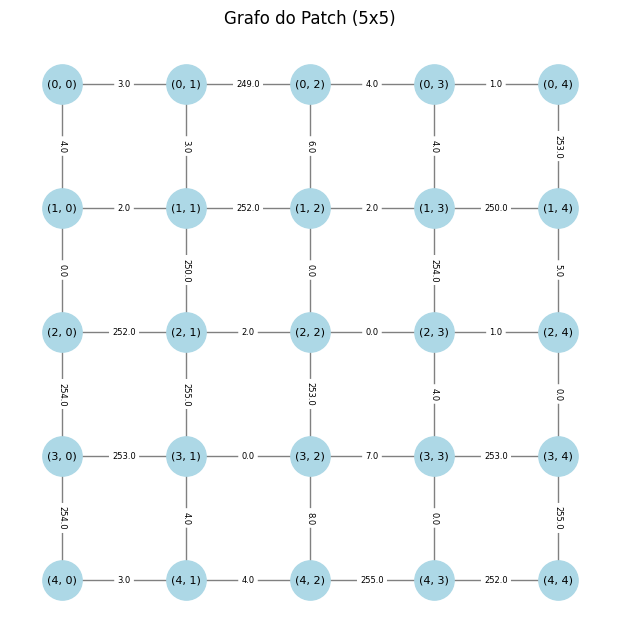

In [14]:
import numpy as np
import cv2
import networkx as nx
import matplotlib.pyplot as plt

def extract_patch(image, center, size=5):
    """Extrai um patch quadrado da imagem, centralizado em `center` com tamanho `size`."""
    x, y = center
    half = size // 2
    return image[x - half:x + half + 1, y - half:y + half + 1]

def build_patch_graph(patch):
    """Cria um grafo onde os nós são pixels e as arestas têm pesos baseados na diferença de intensidade."""
    rows, cols = patch.shape
    G = nx.Graph()

    for i in range(rows):
        for j in range(cols):
            G.add_node((i, j), intensity=patch[i, j])

    for i in range(rows):
        for j in range(cols):
            if i + 1 < rows:
                weight = abs(patch[i, j] - patch[i+1, j])
                G.add_edge((i, j), (i+1, j), weight=weight)
            if j + 1 < cols:
                weight = abs(patch[i, j] - patch[i, j+1])
                G.add_edge((i, j), (i, j+1), weight=weight)

    return G

def plot_graph(G, patch_size):
    """Plota o grafo com os pixels do patch."""
    pos = {node: (node[1], -node[0]) for node in G.nodes()}  # Ajuste da posição no grid
    labels = {node: G.nodes[node]['intensity'] for node in G.nodes()}
    edge_labels = {(u, v): f"{G[u][v]['weight']:.1f}" for u, v in G.edges()}

    plt.figure(figsize=(6, 6))
    nx.draw(G, pos, with_labels=True, node_size=800, node_color="lightblue", font_size=8, edge_color="gray")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, label_pos=0.5)
    plt.title(f"Grafo do Patch ({patch_size}x{patch_size})")
    plt.show()

# Carregar imagem em escala de cinza
image = cv2.imread("ruidosa/ruidosa_salt_pepper.png", cv2.IMREAD_GRAYSCALE)

# Selecionar um patch centralizado em (100, 100)
center = (100, 100)
patch_size = 5
patch = extract_patch(image, center, patch_size)

# Criar o grafo do patch
G = build_patch_graph(patch)

# Visualizar o grafo
plot_graph(G, patch_size)
